In [1]:
import networkx as nx              # For graph analysis (optional)
import matplotlib.pyplot as plt    # Required
import numpy as np                 # Required
import pandas as pd                # Required
import os                          # Required
import sys                         # Required
from matplotlib.lines import Line2D    # For custom legend handles
from matplotlib.patches import Patch   # For patch legend handles

sys.path.append('../../src')          # Add src to path
import accrediff as ad             # AccreDiff package

In [2]:
# ──────────────────────────────────────────────────────
# Nature Style Parameters
# ──────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",        # Serif font
    "font.size": 12,               # Main font size
    "axes.linewidth": 1,           # Axes line width
    "axes.labelsize": 14,          # Axes label size
    "xtick.labelsize": 12,         # X-axis tick label size
    "ytick.labelsize": 12,         # Y-axis tick label size
    "xtick.direction": "in",       # Ticks point inward
    "ytick.direction": "in",
    "xtick.top": False,            # Remove top ticks
    "ytick.right": False,          # Remove right ticks
    "figure.dpi": 300              # High resolution
})

# ──────────────────────────────────────────────────────
# Color Configuration
# ──────────────────────────────────────────────────────
Colors = {
    'Earth': "#1f77b4",
    'Mars': "#d62728",
    'EF': "#8c564b",               # Enstatite chondrites
    'EC': "#ff7f0e",               # Carbonaceous chondrites
    'OC': "#2ca02c",               # Ordinary chondrites
    'CI': "#9467bd",               # CI chondrites
}

# Planetary Composition Analysis at 100 Myr

## Core Workflow
1. Load multiple simulation datasets and classify by planetary mass
2. Normalize by reference compositions (Earth and Mars)
3. Load meteorite reference data
4. Visualize composition ratios (scatter + mean ± 1σ)
5. Calculate weight fraction statistics

In [3]:
# ============================================================================
# SECTION 1: DATA LOADING & PLANET CLASSIFICATION
# ============================================================================

# ── Parameter Definition ────────────────────────────
data_folder = './Tables/'  # ⭐ Modify to change data source

# ── File Loading ────────────────────────────────────
file_paths = [os.path.join(data_folder, f) for f in sorted(os.listdir(data_folder)) 
              if f.endswith('.csv')]
print(f"✓ Found {len(file_paths)} CSV files in {data_folder}")
print()

# ── Initialize Data Dictionary ──────────────────────
keys = [f'sim_{i+1}' for i in range(len(file_paths))]
data_dict = {}

for i, file_path in enumerate(file_paths):
    df = pd.read_csv(file_path, index_col=0)
    data_dict[keys[i]] = df
    print(f"  Loaded: {keys[i]} ({len(df)} rows)")

print()

# ── Data Structure Validation ──────────────────────
sample_df = data_dict['sim_1']
print(f"Sample dataset structure (sim_1):")
print(f"  Rows    : {len(sample_df)}")
print(f"  Columns : {list(sample_df.columns)}")
print()

✓ Found 6 CSV files in ./Tables/

  Loaded: sim_1 (4 rows)
  Loaded: sim_2 (4 rows)
  Loaded: sim_3 (5 rows)
  Loaded: sim_4 (3 rows)
  Loaded: sim_5 (3 rows)
  Loaded: sim_6 (3 rows)

Sample dataset structure (sim_1):
  Rows    : 4
  Columns : ['Time', 'target_id', 'm_e', 'MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2', 'Fe', 'Ni', 'Si', 'O']



In [4]:
# ============================================================================
# SECTION 2: PLANET CLASSIFICATION
# ============================================================================

# ── Add Classification Column ───────────────────────
print(f"✓ Classifying planets by m_e (planetary mass):")
print()

for k, df in data_dict.items():
    if 'm_e' not in df.columns:
        raise KeyError(f"{k} missing required column 'm_e'")
    
    df['Class'] = 'others'
    mask_earth = df['m_e'].between(0.7, 1.3, inclusive='both')
    mask_mars = df['m_e'].between(0.05, 0.3, inclusive='both')
    
    df.loc[mask_earth, 'Class'] = 'Earth_like'
    df.loc[mask_mars, 'Class'] = 'Mars_like'
    
    data_dict[k] = df
    
    # ── Classification Statistics ──────────────────
    counts = df['Class'].value_counts().to_dict()
    print(f"  {k:10s}: {counts}")

print()

# ── Aggregate Classification Results ────────────────
df_Earth = pd.concat([df.loc[df['Class'] == 'Earth_like'] 
                      for df in data_dict.values()], ignore_index=True)
df_Mars = pd.concat([df.loc[df['Class'] == 'Mars_like'] 
                     for df in data_dict.values()], ignore_index=True)

print(f"✓ Classification summary:")
print(f"  Earth_like : {len(df_Earth)} rows")
print(f"  Mars_like  : {len(df_Mars)} rows")
print()

✓ Classifying planets by m_e (planetary mass):

  sim_1     : {'others': 2, 'Earth_like': 1, 'Mars_like': 1}
  sim_2     : {'others': 2, 'Earth_like': 1, 'Mars_like': 1}
  sim_3     : {'others': 3, 'Earth_like': 1, 'Mars_like': 1}
  sim_4     : {'Earth_like': 1, 'others': 1, 'Mars_like': 1}
  sim_5     : {'Earth_like': 1, 'others': 1, 'Mars_like': 1}
  sim_6     : {'Earth_like': 1, 'others': 1, 'Mars_like': 1}

✓ Classification summary:
  Earth_like : 6 rows
  Mars_like  : 6 rows



In [6]:
# ============================================================================
# SECTION 3: LOAD REFERENCE COMPOSITIONS
# ============================================================================

# ── Load Earth Reference Composition ────────────────
Earth_bulk_mg = ad.constants.Earth_bulk_mg
df_Earth_bulk_mg = pd.DataFrame([Earth_bulk_mg], columns=Earth_bulk_mg.keys())

# ── Load Mars Reference Composition ─────────────────
Mars_bulk_mg = ad.constants.Mars_bulk_mg
df_Mars_bulk_mg = pd.DataFrame([Mars_bulk_mg], columns=Mars_bulk_mg.keys())

# ── Load Meteorite Reference Compositions ──────────
meteorites_file = '../Cosmochemistry/Tables/A2_Meteorites_composition.csv'
if not os.path.exists(meteorites_file):
    raise FileNotFoundError(f"Meteorite file not found: {meteorites_file}")

df_Meteorites = pd.read_csv(meteorites_file, index_col=0)
df_Me = df_Meteorites.T

print(f"✓ Loaded reference compositions:")
print(f"  Earth reference : {len(df_Earth_bulk_mg)} rows")
print(f"  Mars reference  : {len(df_Mars_bulk_mg)} rows")
print(f"  Meteorite types : {list(df_Me.index)}")
print()

✓ Loaded reference compositions:
  Earth reference : 1 rows
  Mars reference  : 1 rows
  Meteorite types : ['EF', 'EC', 'OC', 'CI']



In [7]:
# ============================================================================
# SECTION 4: NORMALIZATION BY REFERENCE COMPOSITIONS
# ============================================================================

# ── Select Common Columns ───────────────────────────
common_E = df_Earth.columns.intersection(df_Earth_bulk_mg.columns).tolist()
common_M = df_Mars.columns.intersection(df_Mars_bulk_mg.columns).tolist()

# ── Normalize by Earth Composition ──────────────────
base_Ea = df_Earth_bulk_mg.reindex(columns=common_E[1:]).iloc[0]
df_Earth_norm = df_Earth.reindex(columns=common_E[1:]).div(base_Ea, axis=1)
df_Earth_norm.loc['mean'] = df_Earth_norm.mean(numeric_only=True)
df_Earth_norm.loc['std'] = df_Earth_norm.std(ddof=1, numeric_only=True)  # Sample std dev

# ── Normalize by Mars Composition ───────────────────
base_Ma = df_Mars_bulk_mg.reindex(columns=common_M[1:]).iloc[0]
df_Mars_norm = df_Mars.reindex(columns=common_M[1:]).div(base_Ma, axis=1)
df_Mars_norm.loc['mean'] = df_Mars_norm.mean(numeric_only=True)
df_Mars_norm.loc['std'] = df_Mars_norm.std(ddof=1, numeric_only=True)   # Sample std dev

# ── Normalize Meteorite Data ────────────────────────
df_Me_Ea = df_Me.reindex(columns=common_E[1:]).div(base_Ea, axis=1)
df_Me_Ma = df_Me.reindex(columns=common_M[1:]).div(base_Ma, axis=1)

print(f"✓ Normalization completed:")
print(f"  Earth-normalized: {df_Earth_norm.shape}")
print(f"  Mars-normalized : {df_Mars_norm.shape}")
print(f"  Meteorites normalized to both standards")
print()

✓ Normalization completed:
  Earth-normalized: (8, 9)
  Mars-normalized : (8, 9)
  Meteorites normalized to both standards



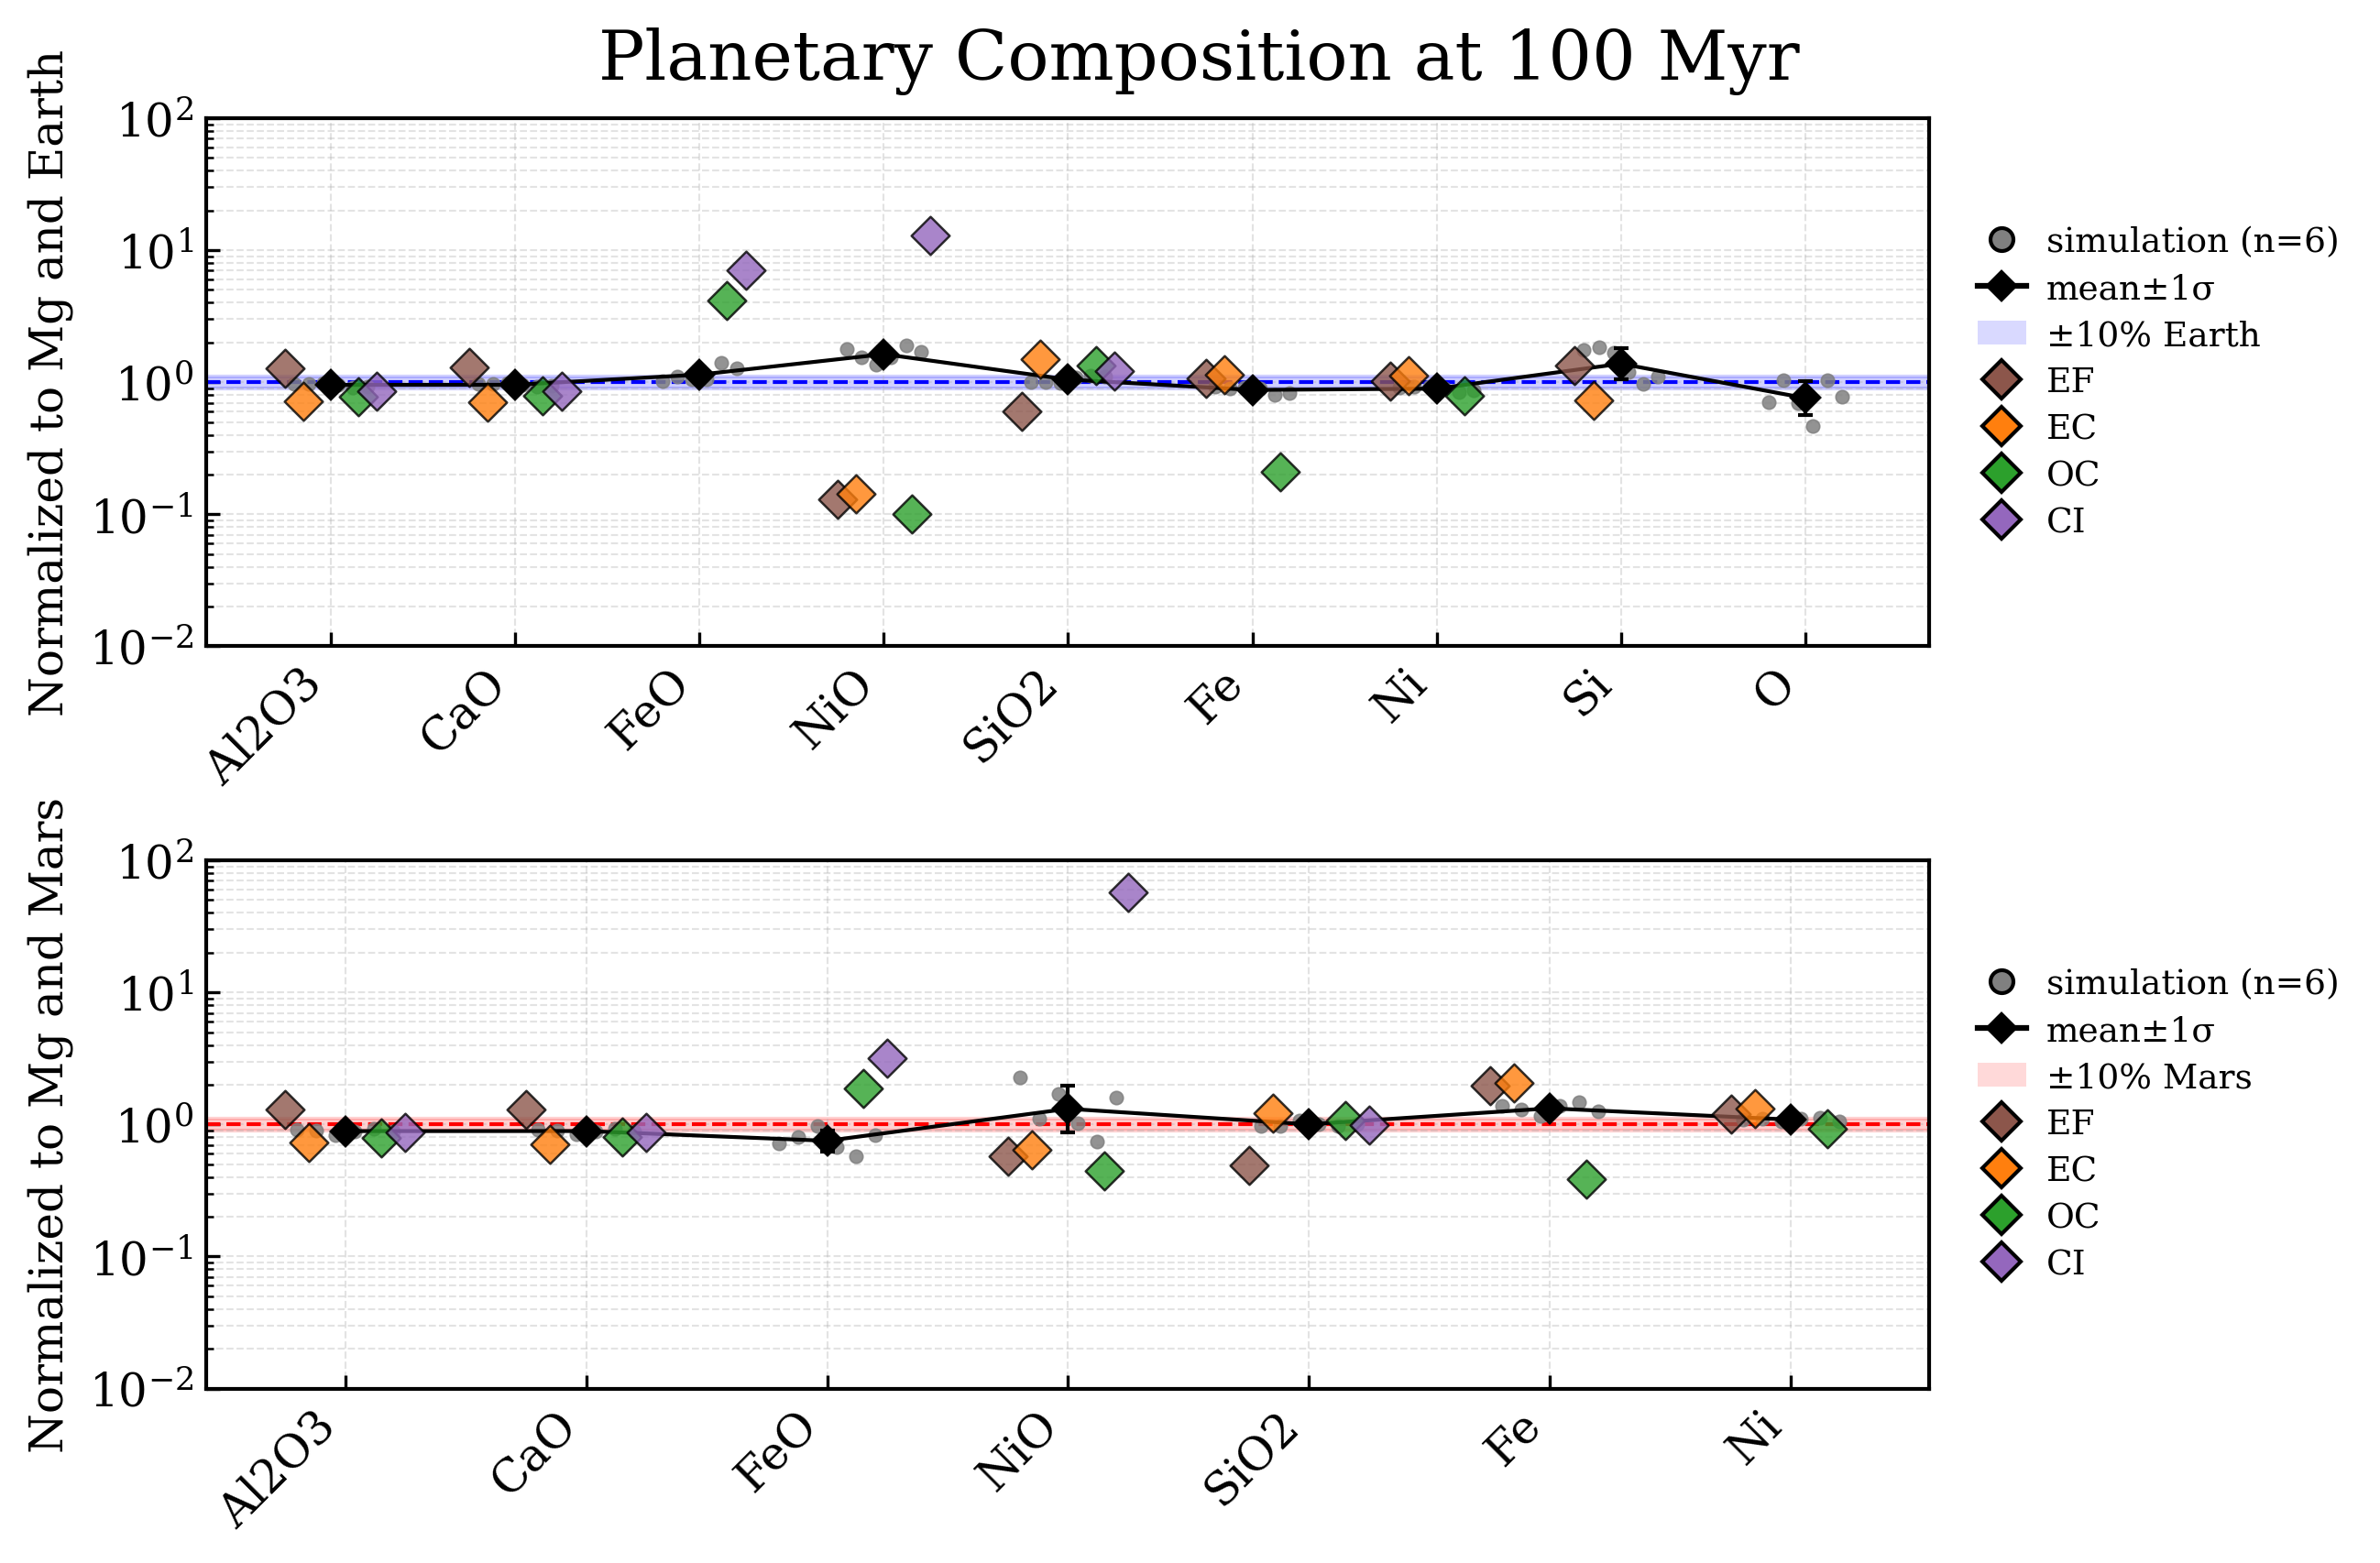

✓ Combined visualization displayed



In [8]:
# ============================================================================
# SECTION 5: VISUALIZATION - COMBINED PLANET COMPOSITION
# ============================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.75))  # 16:9 aspect ratio
fig.suptitle('Planetary Composition at 100 Myr', fontsize=18, y=0.90, x=0.43)

cmap = plt.get_cmap('tab10')
color_indices = [i for i in range(10) if i not in (0, 3)]
meteorite_categories = ['EF', 'EC', 'OC', 'CI']

# ── Plotting Function ───────────────────────────────
def plot_panel(ax, df_norm, elements, ref_color, ref_label, df_meteorite=None):
    """
    Plot normalized composition with scatter and error bars.
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        Target axes object
    df_norm : pd.DataFrame
        Normalized composition data
    elements : list
        Element names to plot
    ref_color : str
        Reference color for shading
    ref_label : str
        Reference label (Earth or Mars)
    df_meteorite : pd.DataFrame, optional
        Meteorite reference data
    """
    # ── Data Preparation ────────────────────────────
    df_plot = df_norm.reindex(columns=elements)
    df_samples = df_plot.drop(index=['mean', 'std'], errors='ignore')
    n = len(df_samples)

    # ── Compute Mean and Std Dev on Log Scale ───────
    mu_lin, lo_lin, hi_lin = [], [], []
    for col in elements:
        vals = pd.to_numeric(df_samples[col], errors='coerce').dropna()
        vals = vals[vals > 0]
        if len(vals) == 0:
            mu_lin.append(np.nan); lo_lin.append(np.nan); hi_lin.append(np.nan)
            continue
        logv = np.log10(vals)
        mu_log = logv.mean()
        sigma_log = logv.std(ddof=1)
        mu_lin.append(10**mu_log)
        lo_lin.append(10**(mu_log - sigma_log))
        hi_lin.append(10**(mu_log + sigma_log))

    mu_lin = np.array(mu_lin)
    lo_lin = np.array(lo_lin)
    hi_lin = np.array(hi_lin)

    # ── Plot Simulation Data ────────────────────────
    x = np.arange(len(elements))
    offsets = np.linspace(-0.2, 0.2, max(n, 1))
    for i, (_, row) in enumerate(df_samples.iterrows()):
        y = row.to_numpy(dtype=float)
        ax.scatter(x + offsets[i % len(offsets)], y,
                   s=12, color='gray', edgecolor='gray', 
                   linewidth=0.4, alpha=0.85, zorder=3)

    # ── Plot Mean ± 1σ Error Bars ──────────────────
    ax.errorbar(x, mu_lin, yerr=[mu_lin - lo_lin, hi_lin - mu_lin],
                fmt='D-', color='k', ms=5, lw=1.0, capsize=2, zorder=4, label='mean')

    # ── Plot Meteorite Data (if provided) ───────────
    meteorite_handles = []
    if df_meteorite is not None:
        meteorite_offsets = {'EF': -0.25, 'EC': -0.15, 'OC': 0.15, 'CI': 0.25}
        for category in meteorite_categories:
            if category in df_meteorite.index:
                row = df_meteorite.loc[category]
                y_vals = [row.get(elem, np.nan) for elem in elements]
                y_vals = np.array(y_vals, dtype=float)
                offset = meteorite_offsets.get(category, 0)
                ax.scatter(x + offset, y_vals,
                           s=50, marker='D', color=Colors[category],
                           edgecolor='k', linewidth=0.6, alpha=0.8, zorder=5)
                meteorite_handles.append(
                    Line2D([0], [0], marker='D', color='none',
                           markerfacecolor=Colors[category], markeredgecolor='k',
                           markersize=7, linestyle='None', label=category)
                )

    # ── Reference Band (±10%) ───────────────────────
    ax.axhspan(0.9, 1.1, color=ref_color, alpha=0.18, zorder=1)
    ax.axhline(1.0, color=ref_color, linestyle="--", linewidth=1)

    # ── Axis Configuration ──────────────────────────
    ax.set_yscale('log')
    ax.set_ylim(0.01, 100)
    ax.set_xticks(x, elements, rotation=45, ha='right')
    ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.35)

    # ── Legend Configuration ────────────────────────
    planet_handle = Line2D([0], [0], marker='o', color='none',
                           markerfacecolor='gray', markeredgecolor='k',
                           markersize=6, linestyle='None', label=f'simulation (n={n})')
    mean_handle = Line2D([0], [0], color='k', marker='D', markersize=5, label='mean±1σ')
    ref_handle = Patch(facecolor=ref_color, alpha=0.15, label=f'±10% {ref_label}')
    
    all_handles = [planet_handle, mean_handle, ref_handle] + meteorite_handles
    ax.legend(handles=all_handles, loc='center left', bbox_to_anchor=(1.02, 0.5),
              frameon=False, fontsize=9, handlelength=1.4,
              handletextpad=0.6, labelspacing=0.4, borderaxespad=0.0)

# ── Upper Panel: Earth-normalized ───────────────────
elements_E = list(df_Earth_norm.columns)
plot_panel(ax1, df_Earth_norm, elements_E, ref_color='blue', 
           ref_label='Earth', df_meteorite=df_Me_Ea)
ax1.set_ylabel('Normalized to Mg and Earth', fontsize=12)

# ── Lower Panel: Mars-normalized ────────────────────
elements_M = [e for e in df_Mars_norm.columns if e not in ('Si', 'O')]
plot_panel(ax2, df_Mars_norm, elements_M, ref_color='red', 
           ref_label='Mars', df_meteorite=df_Me_Ma)
ax2.set_ylabel('Normalized to Mg and Mars', fontsize=12)

# ── Layout & Display ────────────────────────────────
fig.tight_layout(rect=[0.06, 0.06, 0.80, 0.95])
# fig.savefig('composition_comparison_16x9.png', dpi=300, bbox_inches='tight')

plt.show()

print(f"✓ Combined visualization displayed")
print()

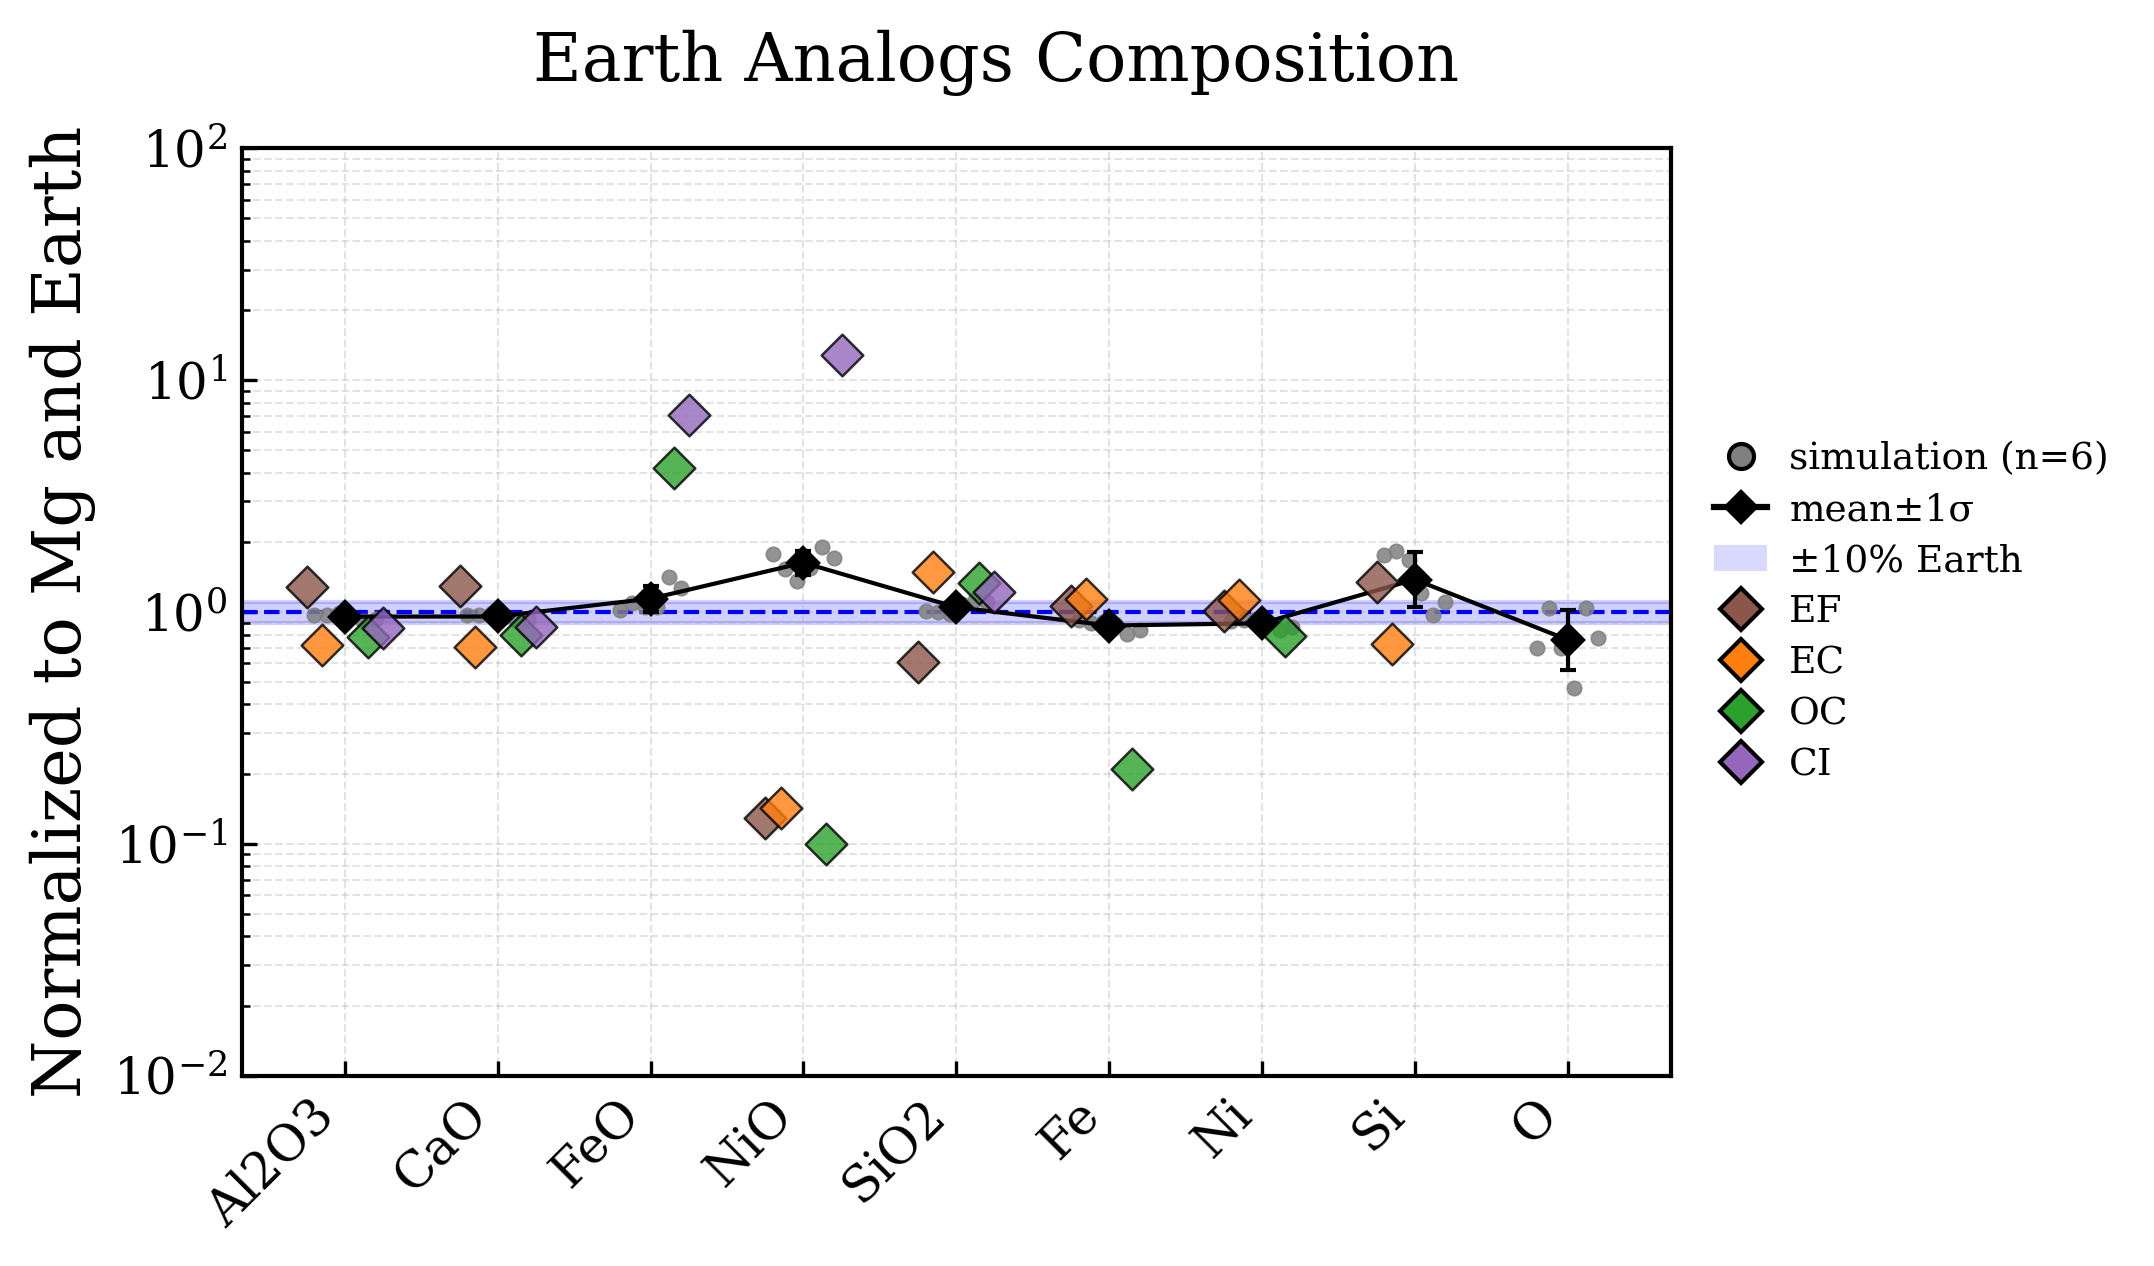

✓ Earth-normalized visualization displayed



In [9]:
# ============================================================================
# SECTION 6: VISUALIZATION - EARTH ANALOGS
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Earth Analogs Composition', fontsize=16, y=0.90, x=0.4)

meteorite_categories = ['EF', 'EC', 'OC', 'CI']

# ── Use plot_panel function from previous cell ─────
elements_E = list(df_Earth_norm.columns)
plot_panel(ax, df_Earth_norm, elements_E, ref_color='blue', 
           ref_label='Earth', df_meteorite=df_Me_Ea)
ax.set_ylabel('Normalized to Mg and Earth', fontsize=16)

fig.tight_layout(rect=[0.06, 0.06, 0.80, 0.95])
plt.show()

print(f"✓ Earth-normalized visualization displayed")
print()

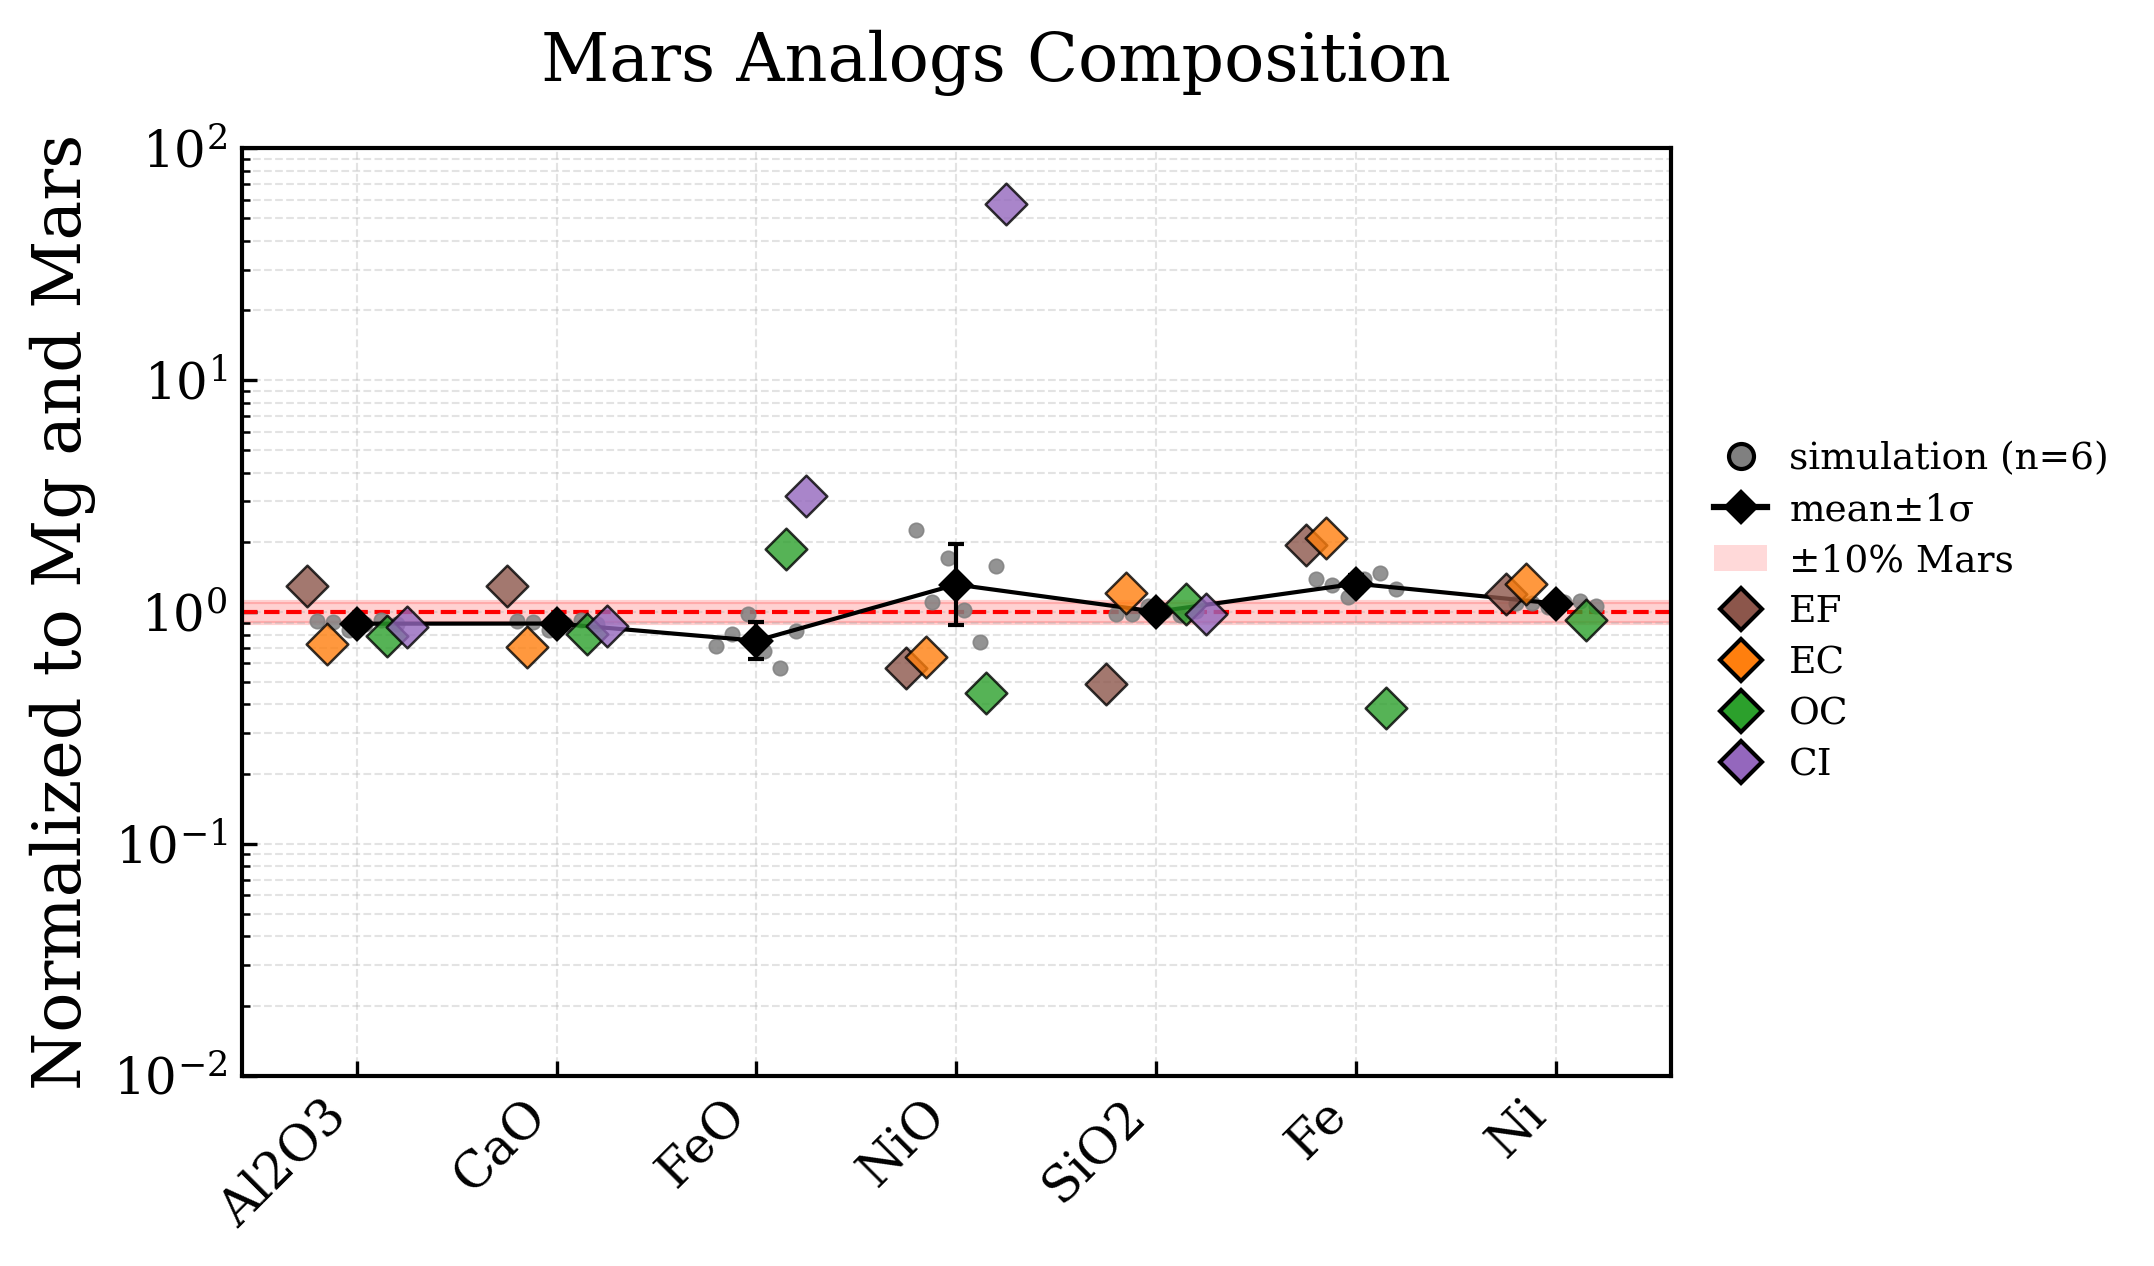

✓ Mars-normalized visualization displayed



In [10]:
# ============================================================================
# SECTION 7: VISUALIZATION - MARS ANALOGS
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Mars Analogs Composition', fontsize=16, y=0.90, x=0.4)

# ── Use plot_panel function from previous cell ─────
elements_M = [e for e in df_Mars_norm.columns if e not in ('Si', 'O')]
plot_panel(ax, df_Mars_norm, elements_M, ref_color='red', 
           ref_label='Mars', df_meteorite=df_Me_Ma)
ax.set_ylabel('Normalized to Mg and Mars', fontsize=16)

fig.tight_layout(rect=[0.06, 0.06, 0.80, 0.95])
plt.show()

print(f"✓ Mars-normalized visualization displayed")
print()

In [11]:
# ============================================================================
# SECTION 8: STATISTICAL ANALYSIS & SUMMARY
# ============================================================================

# ── Element Selection ───────────────────────────────
cols = ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2', 'Fe', 'Ni', 'Si', 'O']

# ── Compute Mean and Std Dev ────────────────────────
print(f"✓ Computing statistics for {len(cols)} elements:")
print()

stats = pd.DataFrame({
    'Earth_like_mean': df_Earth[cols].mean(),
    'Earth_like_std': df_Earth[cols].std(ddof=1),      # Sample std dev
    'Mars_like_mean': df_Mars[cols].mean(),
    'Mars_like_std': df_Mars[cols].std(ddof=1),        # Sample std dev
    'Earth_ref': df_Earth_bulk_mg[cols].iloc[0],
    'Mars_ref': df_Mars_bulk_mg[cols].iloc[0]
})

print(stats)
print()

✓ Computing statistics for 10 elements:

       Earth_like_mean  Earth_like_std  Mars_like_mean  Mars_like_std  \
MgO           1.000000        0.000000        1.000000       0.000000   
Al2O3         0.044396        0.001336        0.040812       0.001440   
CaO           0.064442        0.001829        0.059597       0.002051   
FeO           0.137657        0.018707        0.202957       0.037057   
NiO           0.005861        0.000698        0.001125       0.000444   
SiO2          0.836824        0.048864        0.987769       0.034591   
Fe            0.694670        0.036971        0.574335       0.048821   
Ni            0.040294        0.001664        0.041645       0.000952   
Si            0.105081        0.027772        0.012213       0.007835   
O             0.050953        0.014312        0.005552       0.000776   

       Earth_ref  Mars_ref  
MgO     1.000000  1.000000  
Al2O3   0.046438  0.045784  
CaO     0.067316  0.066778  
FeO     0.119627  0.266037  
NiO     0.

In [12]:
# ============================================================================
# SECTION 9: WEIGHT FRACTION ANALYSIS
# ============================================================================

# ── Load Molar Mass Data ────────────────────────────
Elements = ad.constants.Elements
mantle_items = ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_items = ['Fe', 'Ni', 'Si', 'O']
bulk_items = mantle_items + core_items

# ── Calculate Molar Masses ──────────────────────────
calc_custom = ad.MolarMassCalculator(mass_table=Elements)
for item in mantle_items:
    Elements[item] = calc_custom.molar_mass(item)

# ── Initialize Weight Fraction DataFrame ────────────
df_wt = pd.DataFrame({
    'Earth_like_mean': df_Earth[cols].mean(),
    'Earth_like_std': df_Earth[cols].std(ddof=1),
    'Mars_like_mean': df_Mars[cols].mean(),
    'Mars_like_std': df_Mars[cols].std(ddof=1),
    'Earth_ref': df_Earth_bulk_mg[cols].iloc[0],
    'Mars_ref': df_Mars_bulk_mg[cols].iloc[0]
})

# ── Add Molar Mass Column ───────────────────────────
df_wt['molar_mass'] = [Elements[item] for item in bulk_items]

# ── Convert to Mass Fractions ───────────────────────
df_wt['Earth_analogs_mass'] = df_wt['Earth_like_mean'] * df_wt['molar_mass']
df_wt['Mars_analogs_mass'] = df_wt['Mars_like_mean'] * df_wt['molar_mass']
df_wt['Earth_analogs_std'] = df_wt['Earth_like_std'] * df_wt['molar_mass']
df_wt['Mars_analogs_std'] = df_wt['Mars_like_std'] * df_wt['molar_mass']
df_wt['Earth_ref_mass'] = df_wt['Earth_ref'] * df_wt['molar_mass']
df_wt['Mars_ref_mass'] = df_wt['Mars_ref'] * df_wt['molar_mass']

# ── Normalize to Weight Fractions ───────────────────
df_wt['Earth_analogs_wt'] = df_wt['Earth_analogs_mass'] / df_wt['Earth_analogs_mass'].sum()
df_wt['Earth_analogs_wt_std'] = df_wt['Earth_analogs_std'] / df_wt['Earth_analogs_mass'].sum()
df_wt['Mars_analogs_wt'] = df_wt['Mars_analogs_mass'] / df_wt['Mars_analogs_mass'].sum()
df_wt['Mars_analogs_wt_std'] = df_wt['Mars_analogs_std'] / df_wt['Mars_analogs_mass'].sum()
df_wt['Earth_ref_wt'] = df_wt['Earth_ref_mass'] / df_wt['Earth_ref_mass'].sum()
df_wt['Mars_ref_wt'] = df_wt['Mars_ref_mass'] / df_wt['Mars_ref_mass'].sum()

# ── Display Results ─────────────────────────────────
print(f"✓ Weight fraction calculation completed:")
print()
print(df_wt[['Earth_analogs_wt', 'Mars_analogs_wt', 'Earth_ref_wt', 'Mars_ref_wt']])
print()

# ── Validation: Sum Should Equal 1.0 ────────────────
sums = df_wt[['Earth_analogs_wt', 'Mars_analogs_wt', 'Earth_ref_wt', 'Mars_ref_wt']].sum()
print(f"✓ Sum verification (should be ~1.0):")
print(sums)
print()

✓ Weight fraction calculation completed:

       Earth_analogs_wt  Mars_analogs_wt  Earth_ref_wt  Mars_ref_wt
MgO            0.261765         0.257100      0.259049     0.260054
Al2O3          0.029395         0.026540      0.030428     0.030116
CaO            0.023468         0.021317      0.024260     0.024160
FeO            0.064228         0.093008      0.055236     0.123316
NiO            0.002843         0.000536      0.001713     0.000386
SiO2           0.326540         0.378570      0.307707     0.381692
Fe             0.251943         0.204587      0.284652     0.155613
Ni             0.015357         0.015589      0.016979     0.014485
Si             0.019168         0.002188      0.013317     0.000000
O              0.005294         0.000567      0.006659     0.010178

✓ Sum verification (should be ~1.0):
Earth_analogs_wt    1.0
Mars_analogs_wt     1.0
Earth_ref_wt        1.0
Mars_ref_wt         1.0
dtype: float64

